# Preparing your data for MIDAS

This tutorial walks through preparing a single-cell multi-modal dataset for MIDAS, starting from a publicly downloadable 10x Genomics CITE-seq sample (~5 200 cells, RNA + 32 antibodies). The pipeline is built on scanpy and produces a :class:`MuData` ready to pass to :class:`scmidas.MIDAS`.

The same recipe scales to your own data: replace the download cell with how you load your AnnData(s) and the rest of the steps are identical.

> **In a hurry?** If you just want to use MIDAS, skip this notebook entirely and run any of the bundled tutorials in `docs/source/tutorials/basics/`. They use **already-preprocessed** datasets so you can focus on the model.

> **Looking for the original preprocessing pipeline?** The [reproducibility branch](https://github.com/labomics/midas/tree/reproducibility) (with [docs](https://sc-midas-docs.readthedocs.io/)) contains the scripts used in the manuscript across multiple tissues and modality combinations (PBMC CITE-seq, bone marrow, TEA-seq, multiome). The bundled `demo1` / `demo2` / `demo3` datasets were produced from those scripts and may differ slightly from the manuscript figures because the source data has been updated since publication. The scanpy pipeline below is a self-contained alternative for getting started on your own data — it is not a re-implementation of those scripts.

What you'll learn:

1. Downloading a 10x CITE-seq sample (1 line)
2. Standard scanpy QC (mt%, count thresholds, doublet-aware)
3. Per-modality normalization choices and HVG selection
4. Wrapping per-modality AnnDatas as :class:`MuData` with the contract MIDAS expects
5. Running MIDAS end-to-end and a tiny scanpy downstream (Leiden + UMAP)
6. (Bonus) Synthesizing a *mosaic* MuData from a single dataset, so you can see the layout the demos use


## 1. Setup


In [1]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.basicConfig(level=logging.INFO)

from pathlib import Path
import urllib.request

import anndata as ad
import lightning as L
import matplotlib.pyplot as plt
import mudata as mu
import numpy as np
import pandas as pd
import scanpy as sc

import scmidas

sc.set_figure_params(figsize=(4, 4))
L.seed_everything(42, verbose=False)


42

## 2. Download a public CITE-seq dataset

We use the [5k PBMC protein v3](https://www.10xgenomics.com/datasets/5-k-peripheral-blood-mononuclear-cells-pb-mc-s-from-a-healthy-donor-with-cell-surface-proteins-3-1-standard-3-0-2) sample from 10x Genomics — a healthy-donor PBMC CITE-seq with ~5 200 cells, paired RNA (~33k genes) and 32 antibody capture (ADT) features. The filtered `.h5` is ~17 MB.

In [2]:
DATA_DIR = Path('dataset/_pbmc5k_demo')
DATA_DIR.mkdir(parents=True, exist_ok=True)
H5 = DATA_DIR / '5k_pbmc_protein_v3_filtered_feature_bc_matrix.h5'

if not H5.exists():
    import requests
    url = (
        'https://cf.10xgenomics.com/samples/cell-exp/3.0.2/5k_pbmc_protein_v3/'
        '5k_pbmc_protein_v3_filtered_feature_bc_matrix.h5'
    )
    print(f'Downloading {url} ...')
    r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, stream=True)
    r.raise_for_status()
    with open(H5, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1 << 20):
            f.write(chunk)
print(f'  size: {H5.stat().st_size / 1e6:.1f} MB')

# 10x's CITE-seq h5 packs RNA + antibody capture in one matrix.
adata_all = sc.read_10x_h5(H5, gex_only=False)
adata_all.var_names_make_unique()
print(adata_all)
print('feature_types:', adata_all.var['feature_types'].value_counts().to_dict())


  size: 17.1 MB
AnnData object with n_obs × n_vars = 5247 × 33570
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
feature_types: {'Gene Expression': 33538, 'Antibody Capture': 32}


## 3. Split RNA and ADT into separate AnnData objects

> *This step is generic 10x Genomics handling. It is **not** MIDAS-specific.*

MIDAS expects one :class:`AnnData` **per modality**. Splitting now also lets each modality go through its own QC and normalization.

In [3]:
is_rna = adata_all.var['feature_types'] == 'Gene Expression'
is_adt = adata_all.var['feature_types'] == 'Antibody Capture'

adata_rna = adata_all[:, is_rna].copy()
adata_adt = adata_all[:, is_adt].copy()

print(f'RNA: {adata_rna.shape}, ADT: {adata_adt.shape}')


RNA: (5247, 33538), ADT: (5247, 32)


## 4. Per-modality QC

> *This step is **standard scanpy QC** (mt%, gene/count thresholds), applied per modality.*

The thresholds below mirror those used in the MIDAS paper's R/Seurat preprocessing. Pick your own thresholds for your own data — these are reasonable defaults for 10x PBMC.

In [4]:
# RNA QC: count + gene + mt% thresholds
adata_rna.var['mt'] = adata_rna.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(
    adata_rna, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True,
)

keep_rna = (
    (adata_rna.obs['n_genes_by_counts'].between(500, 6000)) &
    (adata_rna.obs['total_counts'].between(600, 40000)) &
    (adata_rna.obs['pct_counts_mt'] < 15)
)

# ADT QC: count thresholds only
sc.pp.calculate_qc_metrics(adata_adt, percent_top=None, log1p=False, inplace=True)
keep_adt = adata_adt.obs['total_counts'].between(400, 20000)

# Keep cells that pass BOTH modality QCs (intersection).
keep = keep_rna & keep_adt
print(f'Cells passing RNA QC: {int(keep_rna.sum())}/{len(keep_rna)}')
print(f'Cells passing ADT QC: {int(keep_adt.sum())}/{len(keep_adt)}')
print(f'Cells passing BOTH:   {int(keep.sum())}/{len(keep)}')

adata_rna = adata_rna[keep].copy()
adata_adt = adata_adt[keep].copy()


Cells passing RNA QC: 4031/5247
Cells passing ADT QC: 5215/5247
Cells passing BOTH:   4013/5247


## 5. Highly-variable genes for RNA

> *Generic scanpy. ADT keeps all features (only ~30 antibodies — no need to subset).*

MIDAS reads raw count data and applies its own internal `log1p` transform during the forward pass (controlled by the `trsf_before_enc_rna` config). So we **subset by HVG but keep raw counts** — do **not** call `sc.pp.normalize_total` or `sc.pp.log1p` here.

In [5]:
# scanpy's seurat-v3 HVG flavor needs scikit-misc; avoid that extra dep
# by using the classic flow: keep a copy of raw counts, normalize,
# log1p, run HVG, then restore raw counts on the subsetted AnnData.
# MIDAS wants raw counts (it applies its own log1p internally).
import scipy.sparse as sp

raw_counts = adata_rna.X.copy()
raw_var_names = adata_rna.var_names.copy()

sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)
sc.pp.highly_variable_genes(adata_rna, n_top_genes=4000, flavor='seurat')

hvg_mask = adata_rna.var['highly_variable'].values
adata_rna = adata_rna[:, hvg_mask].copy()
col_idx = [raw_var_names.get_loc(g) for g in adata_rna.var_names]
adata_rna.X = raw_counts[:, col_idx]

print(f'RNA after HVG: {adata_rna.shape}')
print(f'ADT (kept all): {adata_adt.shape}')


RNA after HVG: (4013, 4000)
ADT (kept all): (4013, 32)


## 6. Wrap as a MuData with the MIDAS contract

> *This is the **MIDAS-specific** part — and it's the only step that's not pure scanpy.*

The contract is small:

- **One AnnData per modality**, with `.X` holding raw counts (or whatever the model's `trsf_before_enc_*` config expects).
- **A `batch` column** (or any name you want, passed via `batch_key` later) in each modality's `.obs`. It identifies the source batch / donor / sample. Even with **one** batch, this column must exist.
- **Consistent `obs_names`** between modalities for cells that have both — this is how MIDAS knows the cells are paired.

For our single-donor sample, we just label everything `'donor_a'`.

In [6]:
adata_rna.obs['batch'] = 'donor_a'
adata_adt.obs['batch'] = 'donor_a'

mdata = mu.MuData({'rna': adata_rna, 'adt': adata_adt})
print(mdata)


MuData object with n_obs × n_vars = 4013 × 4032
  var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
  2 modalities
    rna:	4013 × 4000
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch'
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg'
    adt:	4013 × 32
      obs:	'n_genes_by_counts', 'total_counts', 'batch'
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'


## 7. Run MIDAS end-to-end

> *MIDAS-specific. This is the same `scmidas.integrate` you'd use on multi-batch data.*

`scmidas.integrate(...)` is a one-call wrapper that calls `setup_mudata`, constructs the model, trains, and writes the joint biological latent to `mdata.obsm['X_midas']`. With a single-donor 5k-cell dataset, training takes ~1 min on a mid-range GPU.

> Single-donor data has **no batch effect to correct**, so this run is mainly a sanity-check that the data layout is valid. For a meaningful integration you'd combine multiple datasets / donors with the same MuData structure (see the demos in `docs/source/tutorials/basics/`).

In [7]:
model = scmidas.integrate(mdata, batch_size=128, max_epochs=100)

print('mdata.obsm[X_midas].shape =', mdata.obsm['X_midas'].shape)


INFO:scmidas.config:The model is initialized with the default configurations.
INFO:scmidas.api:scmidas.integrate(): toy-tuned defaults — batch_size=128, max_epochs=100, lr=0.0003. For real datasets, override max_epochs (e.g. 2000) and consider batch_size=256.
INFO:scmidas.model:setup_mudata: batch_key='batch', batches=['donor_a'], modalities=['rna', 'adt'], dims_x={'rna': [4000], 'adt': [32]}
INFO:scmidas.model:Input data: 
         #CELL  #RNA  #ADT
donor_a   4013  4000    32
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:scmidas.model:Checkpoint successfully saved to "./saved_models/scmidas/model_epoch100_20260509-031133.pt".


mdata.obsm[X_midas].shape = (4013, 32)


## 8. Downstream — Leiden + UMAP

> *Generic single-cell analysis.* Everything `scmidas.integrate` produced lives in `mdata.obsm['X_midas']`, so any tool that takes a `use_rep=` argument works out of the box.

Below we cluster with Leiden, plot the UMAP coloured by cluster, and show how to start hand-annotating cell types from marker genes (or, if you want full automation, drop in [`celltypist`](https://www.celltypist.org/) here).

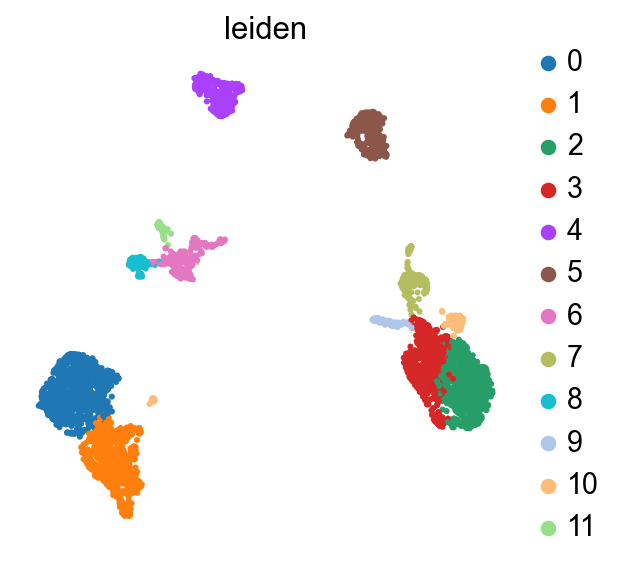

AnnData object with n_obs × n_vars = 4013 × 32
    obs: 'leiden'
    uns: 'neighbors', 'umap', 'leiden_colors'
    obsm: 'X_umap'
    obsp: 'distances', 'connectivities'

In [8]:
# Build a temporary AnnData wrapping X_midas so we can use the full
# scanpy downstream stack. The result (Leiden labels) is copied back
# to mdata.obs so plotting helpers see it.
ad_view = ad.AnnData(X=mdata.obsm['X_midas'], obs=mdata.obs.copy())
sc.pp.neighbors(ad_view, use_rep='X', n_neighbors=15)
sc.tl.leiden(ad_view, resolution=0.5)
mdata.obs['leiden'] = ad_view.obs['leiden'].values

# Plot the UMAP coloured by Leiden cluster.
scmidas.pl.umap(
    mdata, basis='X_midas',
    color=['leiden'], frameon=False,
)


For automated cell-type labelling, [CellTypist](https://www.celltypist.org/) takes the same `mdata['rna']` AnnData and predicts immune cell types from a pre-trained model. We don't run it here to keep dependencies minimal, but a one-liner like:

```python
# pip install celltypist
import celltypist
preds = celltypist.annotate(adata_rna, model='Immune_All_Low.pkl')
mdata.obs['celltypist'] = preds.predicted_labels.predicted_labels.values
```

drops cell-type names directly into `mdata.obs`.

## 9. Bonus — building a *mosaic* MuData (for understanding)

The demos in `docs/source/tutorials/basics/` integrate **mosaic** data: different batches contain different subsets of modalities (e.g. some batches have RNA only, some have ADT only, some have both). This section shows how the layout looks, by **artificially splitting** the single-donor data into three pseudo-batches with different modality availability.

> This is for *understanding the layout*, not for real analysis: there is no genuine batch effect within a single donor.

In [9]:
rng = np.random.default_rng(42)
n = adata_rna.n_obs
idx = rng.permutation(n)
i1, i2 = n // 3, 2 * n // 3
ids_b1, ids_b2, ids_b3 = idx[:i1], idx[i1:i2], idx[i2:]

# b1: RNA only; b2: ADT only; b3: paired RNA+ADT
ad_rna_b1 = adata_rna[ids_b1].copy(); ad_rna_b1.obs['batch'] = 'b1'
ad_rna_b3 = adata_rna[ids_b3].copy(); ad_rna_b3.obs['batch'] = 'b3'
ad_adt_b2 = adata_adt[ids_b2].copy(); ad_adt_b2.obs['batch'] = 'b2'
ad_adt_b3 = adata_adt[ids_b3].copy(); ad_adt_b3.obs['batch'] = 'b3'

# Concatenate per-modality across batches that have that modality.
ad_rna_all = ad.concat([ad_rna_b1, ad_rna_b3], join='outer')
ad_adt_all = ad.concat([ad_adt_b2, ad_adt_b3], join='outer')

mdata_mosaic = mu.MuData({'rna': ad_rna_all, 'adt': ad_adt_all})

print(mdata_mosaic)
print('per-modality batch counts:')
print('  rna:', dict(ad_rna_all.obs['batch'].value_counts()))
print('  adt:', dict(ad_adt_all.obs['batch'].value_counts()))


MuData object with n_obs × n_vars = 4013 × 4032
  2 modalities
    rna:	2675 × 4000
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'batch'
    adt:	2676 × 32
      obs:	'n_genes_by_counts', 'total_counts', 'batch'
per-modality batch counts:
  rna: {'b3': 1338, 'b1': 1337}
  adt: {'b2': 1338, 'b3': 1338}


You can now pass `mdata_mosaic` to `scmidas.MIDAS.setup_mudata` and `scmidas.MIDAS(...)`; MIDAS will infer the mosaic structure (which batches lack which modalities) automatically. See `demo2.ipynb` for the same idea on a real 8-batch RNA+ADT dataset.

## Where to go next

- **Demo notebooks** (`docs/source/tutorials/basics/`) walk through MIDAS on three preprocessed datasets, with mosaic and tri-modal cases.
- **Quickstart** (`examples/quickstart.ipynb`) is the 5-line "does this work" path with the bundled toy data.
- **Reproducibility branch** ([github](https://github.com/labomics/midas/tree/reproducibility), [docs](https://sc-midas-docs.readthedocs.io/)) contains the original preprocessing scripts spanning the tissues and modality combinations used in the manuscript, including ATAC peak calling and batch-aware HVG selection.

For an even shorter pipeline (single-cell, single-modality preprocessing), refer to the standard scanpy [Preprocessing and clustering](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering-2017.html) tutorial — every step before "wrap as MuData" is the same.
